In [ ]:
!pip -q install pandas numpy matplotlib seaborn nltk wordcloud scikit-learn

In [1]:
import re
import textwrap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer

import nltk
nltk.download("punkt")
nltk.download("punkt_tab")

from nltk.tokenize import sent_tokenize

sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 120)


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [2]:
df_lb = pd.read_csv("lecturebank_extracted_text.csv")

df_lb.head()

,ID,Title,Topic,label,URL,Venue,Year,url_type,text
0,6279,The Perceptron,515,Perceptron,https://www.cs.rpi.edu/~magdon/courses/LFD-Slides/SlidesLect02-C.pdf,Rensselaer Polytechnic Institute,2020,pdf,LearningFromDataLecture2ThePerceptronTheLearningSetupASimpleLearningAlgorithm:PLAOtherViewsofLearningIsLearningFeasi...
1,1859,Deep Network Models,107,Machine Learning,https://www.cs.cornell.edu/courses/cs6780/2019sp/lecture/10-deep_6up.pdf,Cornell University,2019,pdf,Deep Network Models CS6780 – Advanced Machine Learning Spring 2019 Thorsten Joachims Cornell University Reading: Mur...
2,6803,Advanced Policy Gradients,716,716,https://rail.eecs.berkeley.edu/deeprlcourse/static/slides/lec-9.pdf,UC Berkeley,2021,pdf,Off-Policy Policy Gradient CS 185/285 Instructor: Sergey Levine UC Berkeley Part 1: Back to policy gradients Why do ...
3,6305,Validation and Model Selection,712,"Neural Architectures, Training Neural Networks",https://www.cs.rpi.edu/~magdon/courses/LFD-Slides/SlidesLect13.pdf,Rensselaer Polytechnic Institute,2020,pdf,Learning From Data Lecture 13 Validation and Model Selection The Validation Set Model Selection Cross Validation M. ...
4,7194,Deep learning 11.1. Generative Adversarial Networks,746,"GAN, GAT",https://fleuret.org/dlc/materials/dlc-handout-11-1-GAN.pdf,University of Geneva,2022,pdf,Deep learning 11.1. Generative Adversarial Networks Fran¸cois Fleuret https://fleuret.org/dlc/ A popular approach to...


In [3]:
def safe_sentence_count(text):
    text = "" if pd.isna(text) else str(text)

    if not text.strip():
        return 0

    try:
        return len(sent_tokenize(text))
    except LookupError:
        return len([s for s in re.split(r"[.!?]+", text) if s.strip()])

def basic_text_stats(df, text_col="text"):
    out = df.copy()

    out[text_col] = out[text_col].fillna("").astype(str)

    out["char_count"] = out[text_col].str.len()

    out["word_count"] = out[text_col].apply(
        lambda x: len(re.findall(r"\b\w+\b", x))
    )

    out["sentence_count"] = out[text_col].apply(safe_sentence_count)

    out["avg_words_per_sentence"] = (
        out["word_count"] / out["sentence_count"].replace(0, np.nan)
    )

    out["url_count"] = out[text_col].str.count(r"https?://|www\.")

    out["email_count"] = out[text_col].str.count(
        r"\b[\w\.-]+@[\w\.-]+\.\w+\b"
    )

    out["alpha_ratio"] = out[text_col].apply(
        lambda x: sum(ch.isalpha() for ch in x) / max(len(x), 1)
    )

    out["too_short_sentence_model"] = (
        (out["sentence_count"] < 2) |
        (out["word_count"] < 20)
    )

    out["too_noisy_sentence_model"] = (
        (out["url_count"] >= 5) |
        (out["word_count"] == 0)
    )

    out["usable_sentence_level"] = (
        ~out["too_short_sentence_model"] &
        ~out["too_noisy_sentence_model"]
    )
    out["exceeds_bert_limit"] = out["word_count"] > 350

    return out

In [4]:
eda_lb = basic_text_stats(df_lb)

print("LectureBank full-text EDA ready.")
print("Documents:", len(eda_lb))
print("Topics:", eda_lb["label"].nunique())

LectureBank full-text EDA ready.
Documents: 291
Topics: 73


In [5]:
pd.DataFrame({
    "dataset": ["LectureBank extracted text"],
    "document_count": [len(eda_lb)],
    "topic_count": [eda_lb["label"].nunique()]
})

,dataset,document_count,topic_count
0,LectureBank extracted text,291,73


In [6]:
def plot_distribution(df, col, title, bins=60):
    plt.figure(figsize=(8, 4))
    capped = df[col].clip(upper=df[col].quantile(0.99))
    sns.histplot(capped, bins=bins)
    plt.title(f"{title} (99th percentile capped)")
    plt.title(title)
    plt.xlabel(col.replace("_", " ").title())
    plt.ylabel("Documents")
    plt.show()

def plot_label_distribution(df, label_col="label", top_n=30, title="Topic Distribution"):
    counts = df[label_col].value_counts().head(top_n)

    plt.figure(figsize=(9, max(4, top_n * 0.25)))
    sns.barplot(x=counts.values, y=counts.index)

    plt.title(title)
    plt.xlabel("Documents")
    plt.ylabel("Topic")
    plt.show()


def vocabulary_stats(texts, max_features=50000, min_df=2, stop_words="english"):
    vectorizer = CountVectorizer(
        lowercase=True,
        stop_words=stop_words,
        min_df=min_df,
        max_features=max_features
    )

    X = vectorizer.fit_transform(texts.fillna(""))

    vocab = vectorizer.get_feature_names_out()
    freqs = np.asarray(X.sum(axis=0)).ravel()

    vocab_df = pd.DataFrame({
        "term": vocab,
        "count": freqs
    }).sort_values("count", ascending=False)

    stats = pd.Series({
        "vocabulary_size": len(vocab),
        "total_counted_tokens": int(freqs.sum()),
        "mean_counted_terms_per_doc": float(X.sum(axis=1).mean()),
        "median_counted_terms_per_doc": float(
            np.median(np.asarray(X.sum(axis=1)).ravel())
        )
    })

    return stats, vocab_df, X

def modelling_quality_summary(df):
    return pd.Series({
        "documents": len(df),
        "too_short_count": int(df["too_short_sentence_model"].sum()),
        "too_short_pct": round(df["too_short_sentence_model"].mean() * 100, 2),
        "too_noisy_count": int(df["too_noisy_sentence_model"].sum()),
        "too_noisy_pct": round(df["too_noisy_sentence_model"].mean() * 100, 2),
        "usable_sentence_level_count": int(df["usable_sentence_level"].sum()),
        "usable_sentence_level_pct": round(df["usable_sentence_level"].mean() * 100, 2),
        "exceeds_bert_limit_pct": round(df["exceeds_bert_limit"].mean() * 100, 2)
    })


def document_examples(df, text_col="text"):
    q1, q2 = df["word_count"].quantile([0.33, 0.66])

    groups = {
        "SHORT DOCUMENTS": df[df["word_count"] <= q1].sort_values("word_count").head(3),
        "MEDIUM DOCUMENTS": df[
            (df["word_count"] > q1) &
            (df["word_count"] <= q2)
        ].sample(min(3, len(df)), random_state=42),
        "LONG DOCUMENTS": df[df["word_count"] > q2].sort_values(
            "word_count",
            ascending=False
        ).head(3)
    }

    for name, rows in groups.items():
        print("\n" + "=" * 80)
        print(name)
        print("=" * 80)

        for _, row in rows.iterrows():
            print("\nTopic:", row["label"])
            print("Words:", row["word_count"])
            print("Sentences:", row["sentence_count"])

            preview = row[text_col].replace("\n", " ")
            print(textwrap.shorten(preview, width=700))




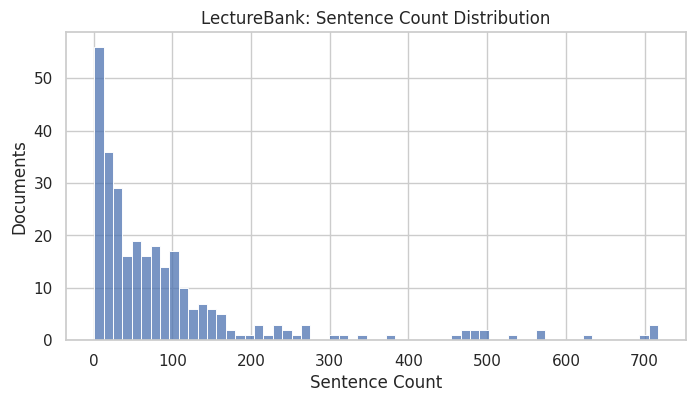

In [7]:
plot_distribution(
    eda_lb,
    "sentence_count",
    "LectureBank: Sentence Count Distribution"
)

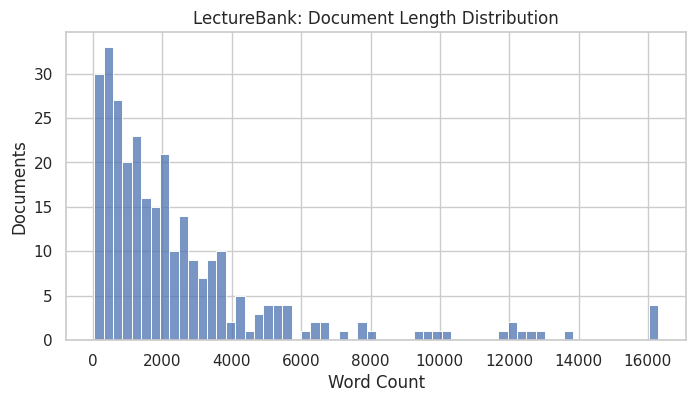

In [8]:
plot_distribution(
    eda_lb,
    "word_count",
    "LectureBank: Document Length Distribution"
)

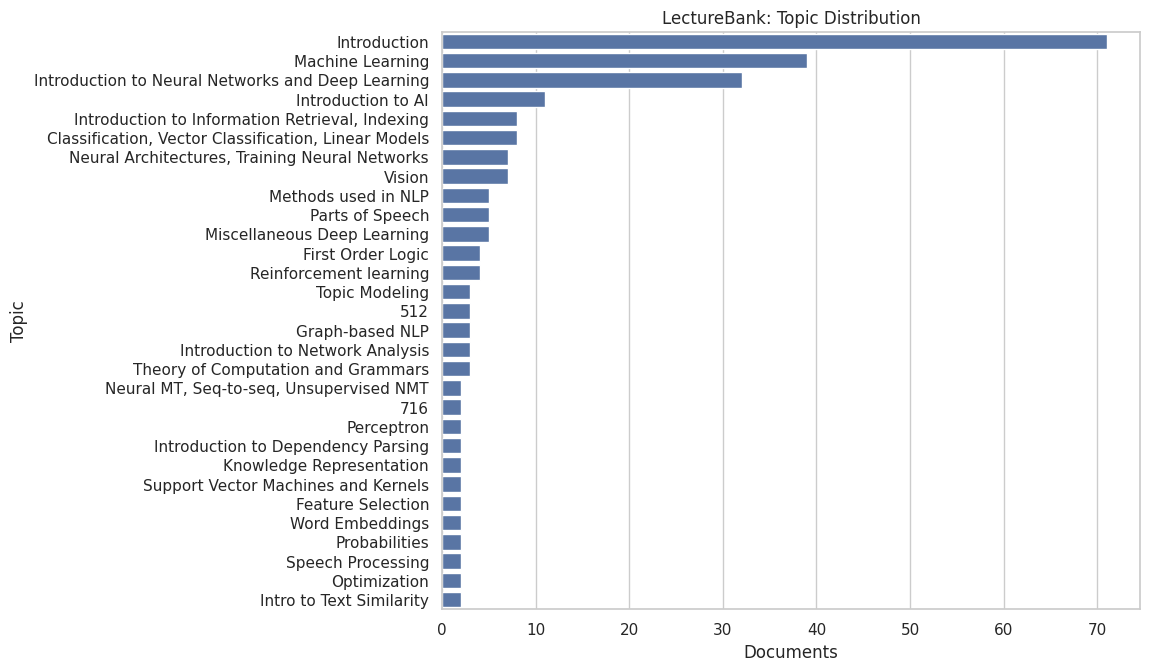

In [9]:
plot_label_distribution(
    eda_lb,
    title="LectureBank: Topic Distribution"
)

In [10]:
vocab_stats_lb, vocab_lb, X_lb = vocabulary_stats(eda_lb["text"])

vocab_stats_lb

,0
vocabulary_size,11248.000000
total_counted_tokens,365795.000000
mean_counted_terms_per_doc,1257.027491
median_counted_terms_per_doc,837.000000


In [11]:
vocab_lb.head(30)

,term,count
2311,cid,14861
6030,learning,2487
3130,data,1810
6660,model,1515
9020,set,1388
56,10,1235
4130,example,1199
10111,training,1152
5973,language,1073
3207,deep,1070


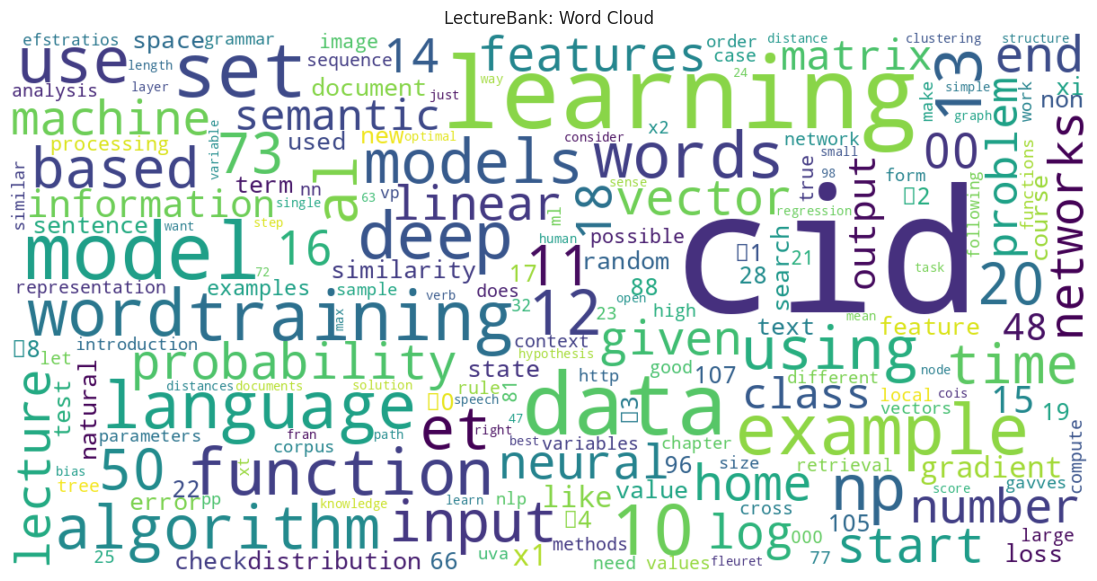

In [12]:
wc_lb = WordCloud(
    width=1200,
    height=600,
    background_color="white"
).generate_from_frequencies(
    dict(zip(vocab_lb["term"], vocab_lb["count"]))
)

plt.figure(figsize=(14, 7))
plt.imshow(wc_lb, interpolation="bilinear")
plt.axis("off")
plt.title("LectureBank: Word Cloud")
plt.show()

In [13]:
document_examples(eda_lb)


SHORT DOCUMENTS

Topic: Feature Selection
Words: 33
Sentences: 1
Lecture 14 Dimensionality Reduction II: Feature Extraction short version STAT 479: Machine Learning, Fall 2018 Sebastian Raschka http://stat.wisc.edu/~sraschka/teaching/stat479-fs2018/ Sebastian Raschka STAT 479: Machine Learning FS 2018

Topic: CKY Parsing
Words: 48
Sentences: 1
CS447: Natural Language Processing http://courses.engr.illinois.edu/cs447 Lecture 9: The CKY parsing algorithm Julia Hockenmaier juliahmr@illinois.edu 3324 Siebel Center Last lecture’s key concepts Natural language syntax Constituents Dependencies Context-free grammar Arguments and modiﬁers Recursion in natural language CS447 Natural Language Processing

Topic: Introduction
Words: 59
Sentences: 1
CS447: Natural Language Processing http://courses.engr.illinois.edu/cs447 Lecture 3: Language models Julia Hockenmaier juliahmr@illinois.edu 3324 Siebel Center Last lecture’s key concepts Morphology (word structure): stems, afﬁxes Derivational vs. inﬂec

In [14]:
modelling_quality_summary(eda_lb)

,0
documents,291.00
too_short_count,16.00
too_short_pct,5.50
too_noisy_count,41.00
too_noisy_pct,14.09
usable_sentence_level_count,234.00
usable_sentence_level_pct,80.41
exceeds_bert_limit_pct,86.25


In [15]:
# Create a LectureBank version for modelling pipeline.
#
# Filter steps:
# 1. Keep only documents that passed EDA quality checks.
# 2. Drop rows where label is a stray topic ID (digits only) that didn't merge with taxonomy.
# 3. Keep only classes with >= 4 documents (smaller classes are too sparse to cluster).

df_peer_lb = eda_lb[eda_lb["usable_sentence_level"]][["text", "label"]].copy()

# Drop garbage labels like "2", "512", "716"
df_peer_lb = df_peer_lb[
    ~df_peer_lb["label"].astype(str).str.match(r'^\d+$')
]

# Keep only classes with >= 4 docs
counts = df_peer_lb["label"].value_counts()
keep_classes = counts[counts >= 4].index.tolist()
df_peer_lb = df_peer_lb[df_peer_lb["label"].isin(keep_classes)].reset_index(drop=True)

df_peer_lb["split"] = "all"
df_peer_lb = df_peer_lb[["text", "split", "label"]]

df_peer_lb.to_csv("corpus_lecturebank.tsv", sep="\t", index=False, header=False)

print(f"Corpus saved: {len(df_peer_lb)} docs, {df_peer_lb['label'].nunique()} classes")
print("\nClass distribution:")
print(df_peer_lb["label"].value_counts())

Corpus saved: 155 docs, 10 classes

Class distribution:
label
Introduction                                            54
Machine Learning                                        31
Introduction to Neural Networks and Deep Learning       28
Introduction to AI                                      11
Introduction to Information Retrieval, Indexing          7
Neural Architectures, Training Neural Networks           6
Classification, Vector Classification, Linear Models     6
Parts of Speech                                          4
Reinforcement learning                                   4
First Order Logic                                        4
Name: count, dtype: int64
